# 🎯 MathQuest — Placement Model (Pre-Test)
## Menentukan Level Awal Siswa Berdasarkan Hasil Pre-Test

---

### Format Data dalam Pipeline ini:

| Tahap | Format |
|-------|--------|
| **Input dari Backend** | `user_id, no_soal, materi, benar_salah, waktu_pengerjaan` |
| **Setelah diproses model** | `user_id, materi, akurasi_per_materi, avg_waktu_per_materi` |
| **Output ke Backend** | `user_id, mulai_dari_modul, confidence` |

### Target Performa:
- ✅ Akurasi minimal **85%**
- ✅ MAE maksimal **0.02**

### Alur Notebook:
1. Install & Import
2. Konfigurasi
3. Custom Components (Layer, Loss, Callback)
4. Load Data (CSV / JSON)
5. Preprocessing — sesuai format yang disepakati
6. Split Data
7. Bangun Model
8. Training
9. Evaluasi (akurasi + MAE)
10. Simpan Model
11. Inference — output sesuai format ke backend


## Step 1 — Install Library

In [1]:
# Install semua library yang dibutuhkan
# Jalankan sekali saja — kalau sudah pernah install, skip cell ini
!pip install tensorflow numpy pandas scikit-learn joblib matplotlib


[notice] A new release of pip is available: 25.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Step 2 — Import Library

In [2]:
# os: untuk membuat folder dan mengecek keberadaan file
import os

# numpy: operasi matematika pada array angka
import numpy as np

# pandas: membaca dan memanipulasi data tabel (seperti Excel)
import pandas as pd

# matplotlib: membuat grafik dan visualisasi
import matplotlib.pyplot as plt

# joblib: menyimpan dan memuat objek Python ke file (untuk scaler)
import joblib

# json: membaca file JSON dan mengubah dict menjadi format JSON
import json

# tensorflow: library utama untuk membangun dan melatih model Deep Learning
import tensorflow as tf

# keras: bagian TensorFlow yang menyediakan API tingkat tinggi
from tensorflow import keras

# train_test_split: memisahkan data menjadi bagian training dan testing
from sklearn.model_selection import train_test_split

# MinMaxScaler: menormalisasi angka ke skala 0 sampai 1
from sklearn.preprocessing import MinMaxScaler

# mean_absolute_error: menghitung MAE — salah satu metrik evaluasi model
from sklearn.metrics import mean_absolute_error

# classification_report: laporan akurasi detail per kelas
# confusion_matrix: tabel prediksi benar vs salah per kelas
from sklearn.metrics import classification_report, confusion_matrix

# Cek versi TensorFlow
print("TensorFlow versi:", tf.__version__)
print("Semua library berhasil diimport ✓")

TensorFlow versi: 2.21.0
Semua library berhasil diimport ✓


## Step 3 — Konfigurasi

In [3]:
# ── Pemetaan kelas ke nama level ──────────────────────────────────────────────
# Key   = angka label yang dipakai model (0, 1, 2)
# Value = nama level yang akan dikirim ke backend
LABEL_MAP = {
    0: "pemula",    # akurasi overall < 40%
    1: "menengah",  # akurasi overall 40% - 70%
    2: "mahir",     # akurasi overall > 70%
}

# ── Pemetaan level ke nomor modul awal ────────────────────────────────────────
# Ini yang akan dikirim ke backend sebagai "mulai_dari_modul"
# Sesuaikan dengan quest map yang dibuat tim Full-Stack
MODUL_MAP = {
    0: 1,   # pemula   → mulai dari modul 1
    1: 4,   # menengah → mulai dari modul 4
    2: 8,   # mahir    → mulai dari modul 8
}

# ── Batas akurasi untuk menentukan label ──────────────────────────────────────
# Sesuaikan batas ini jika diperlukan setelah melihat distribusi data nyata
BATAS_PEMULA   = 0.30   # akurasi < 40% → pemula
BATAS_MENENGAH = 0.50   # akurasi 40-70% → menengah
                         # akurasi > 70% → mahir

# ── Path file ─────────────────────────────────────────────────────────────────
# Folder untuk menyimpan hasil training
MODEL_PATH    = "saved_model/placement_model.keras"
SCALER_PATH   = "saved_model/placement_scaler.pkl"
FEATURES_PATH = "saved_model/feature_names.txt"

# Buat folder jika belum ada
os.makedirs("saved_model",      exist_ok=True)
os.makedirs("tensorboard_logs", exist_ok=True)

print("Konfigurasi selesai ✓")
print(f"  Batas pemula   : akurasi < {BATAS_PEMULA}")
print(f"  Batas menengah : akurasi {BATAS_PEMULA} - {BATAS_MENENGAH}")
print(f"  Batas mahir    : akurasi > {BATAS_MENENGAH}")

Konfigurasi selesai ✓
  Batas pemula   : akurasi < 0.3
  Batas menengah : akurasi 0.3 - 0.5
  Batas mahir    : akurasi > 0.5


## Step 4 — Custom Components
### 4a. Custom Layer: TopicAttentionLayer

In [4]:
# ── TopicAttentionLayer ───────────────────────────────────────────────────────
# Custom layer buatan sendiri — tidak ada di TensorFlow bawaan
#
# Tugasnya: memberi bobot perhatian pada fitur per materi
# Materi yang konsisten salah dijawab siswa → diberi perhatian lebih
# Cara kerjanya: setiap fitur input dikalikan dengan bobot 0.0 - 1.0
#   - Bobot mendekati 1.0 = fitur ini sangat penting
#   - Bobot mendekati 0.0 = fitur ini kurang relevan
# Bobot-bobot ini dipelajari sendiri oleh model selama training

class TopicAttentionLayer(keras.layers.Layer):

    def __init__(self, units, **kwargs):
        # Panggil __init__ dari parent class — wajib dilakukan
        super().__init__(**kwargs)

        # Simpan jumlah unit (= jumlah fitur input)
        self.units = units

        # Dense internal untuk menghasilkan bobot perhatian (nilai 0.0 - 1.0)
        # activation='sigmoid' memastikan outputnya selalu antara 0 dan 1
        self.attention_dense = keras.layers.Dense(units, activation="sigmoid")

    def call(self, inputs):
        # Hitung bobot perhatian untuk setiap fitur
        attention_weights = self.attention_dense(inputs)

        # Kalikan input asli dengan bobotnya
        # Fitur penting (bobot ~1.0) → nilainya hampir tidak berubah
        # Fitur tidak relevan (bobot ~0.0) → nilainya mendekati nol
        return inputs * attention_weights

    def get_config(self):
        # Wajib ada agar model bisa disimpan dan di-load ulang tanpa error
        config = super().get_config()
        config.update({"units": self.units})
        return config

print("TopicAttentionLayer berhasil didefinisikan ✓")

TopicAttentionLayer berhasil didefinisikan ✓


### 4b. Custom Loss: WeightedCrossEntropyLoss

In [5]:
# ── WeightedCrossEntropyLoss ──────────────────────────────────────────────────
# Custom loss function yang memberi penalti lebih besar untuk kesalahan
# memprediksi siswa KESULITAN (pemula) sebagai MAHIR
#
# Kenapa diperlukan?
#   Loss standar: semua kesalahan dihukum sama berat
#   Custom loss : siswa pemula yang salah diprediksi → dihukum 3x lebih berat
#
# Dampak ke training:
#   Model akan lebih berhati-hati dalam memprediksi kelas pemula
#   → Lebih aman untuk siswa yang sebenarnya butuh bantuan

class WeightedCrossEntropyLoss(keras.losses.Loss):

    def __init__(self, class_weights=None, name="weighted_cross_entropy", **kwargs):
        super().__init__(name=name, **kwargs)

        # Simpan sebagai list Python biasa supaya get_config() tidak error
        # Default: pemula (kelas 0) dihukum 3x lebih berat dari kelas lain
        self.class_weights_list = class_weights if class_weights else [3.0, 1.0, 1.0]

        # Buat versi tensor untuk dipakai dalam perhitungan TensorFlow
        # tf.constant = tensor yang nilainya tetap (tidak berubah saat training)
        self.class_weights_tensor = tf.constant(
            self.class_weights_list, dtype=tf.float32
        )

    def call(self, y_true, y_pred):
        # y_true = label asli,    contoh: [0, 2, 1, 0]
        # y_pred = prediksi model, contoh: [[0.7,0.2,0.1], ...]

        # LANGKAH 1: Hitung cross entropy standar per siswa
        # sparse = y_true berupa integer (0,1,2), bukan one-hot
        # from_logits=False karena output layer pakai softmax
        ce_loss = keras.losses.sparse_categorical_crossentropy(
            y_true, y_pred, from_logits=False
        )
        # ce_loss = satu nilai loss per siswa, misal: [1.2, 0.3, 0.8, 0.4]

        # LANGKAH 2: Ubah y_true ke integer supaya bisa jadi index
        y_true_int = tf.cast(y_true, tf.int32)

        # LANGKAH 3: Ambil bobot sesuai kelas asli tiap siswa
        # tf.gather = ambil elemen ke-i dari class_weights sesuai indeks y_true
        # Contoh: y_true=[0,2,1,0] → sample_weights=[3.0, 1.0, 1.0, 3.0]
        sample_weights = tf.gather(self.class_weights_tensor, y_true_int)

        # LANGKAH 4: Kalikan loss tiap siswa dengan bobotnya
        # Siswa pemula (bobot 3.0) → loss-nya dikali 3 → hukuman lebih berat
        weighted_loss = ce_loss * sample_weights

        # LANGKAH 5: Rata-ratakan semua loss dalam satu batch
        return tf.reduce_mean(weighted_loss)

    def get_config(self):
        # Wajib ada agar model.save() bekerja dengan benar
        config = super().get_config()
        config.update({"class_weights": self.class_weights_list})
        return config

    @classmethod
    def from_config(cls, config):
        # Diperlukan saat model di-load dari file
        return cls(**config)

print("WeightedCrossEntropyLoss berhasil didefinisikan ✓")

WeightedCrossEntropyLoss berhasil didefinisikan ✓


### 4c. Custom Callback: TrainingLogger

In [6]:
# ── TrainingLogger ────────────────────────────────────────────────────────────
# Callback yang menyimpan log metrik training ke CSV setiap epoch selesai
# Berguna untuk monitoring proses training dan dokumentasi eksperimen

class TrainingLogger(keras.callbacks.Callback):

    def __init__(self, log_path="saved_model/training_log.csv"):
        super().__init__()
        # Path file CSV tempat log disimpan
        self.log_path = log_path
        # List untuk menampung riwayat log selama training berlangsung
        self.logs_history = []

    def on_epoch_end(self, epoch, logs=None):
        # on_epoch_end() dipanggil otomatis oleh TensorFlow setiap epoch selesai
        # Parameter 'logs' berisi dict metrik epoch tersebut

        # Kumpulkan semua metrik epoch ini
        entry = {
            "epoch"        : epoch + 1,                        # +1 karena dimulai dari 0
            "loss"         : round(logs.get("loss",         0), 4),
            "accuracy"     : round(logs.get("accuracy",     0), 4),
            "val_loss"     : round(logs.get("val_loss",     0), 4),
            "val_accuracy" : round(logs.get("val_accuracy", 0), 4),
        }

        # Tambahkan ke riwayat
        self.logs_history.append(entry)

        # Simpan ke CSV — overwrite setiap epoch
        # Sehingga file selalu berisi log terbaru sampai epoch terakhir
        pd.DataFrame(self.logs_history).to_csv(self.log_path, index=False)

print("TrainingLogger berhasil didefinisikan ✓")

TrainingLogger berhasil didefinisikan ✓


## Step 5 — Load Data

> ### BACA INI DULU
> Di cell ini ada **3 pilihan** cara memasukkan data:
> - **Opsi A:** Pakai file **CSV**
> - **Opsi B:** Pakai file **JSON**
> - **Opsi C:** Pakai **data dummy** (sementara, sebelum data nyata tersedia)
>
> **Jalankan hanya SATU opsi** sesuai data yang kalian punya.
> Setelah berhasil load, lanjut ke Step 6.

### Format Data yang Diharapkan:
| Kolom | Tipe | Keterangan |
|-------|------|------------|
| `user_id` | string | ID unik siswa |
| `no_soal` | integer | Nomor urut soal |
| `materi` | string | Nama materi/topik soal |
| `benar_salah` | integer | 1 = benar, 0 = salah |
| `waktu_pengerjaan` | float | Waktu dalam detik |


### Opsi A — Load dari CSV

In [7]:
# # ── OPSI A: Load dari file CSV ────────────────────────────────────────────────
# # Gunakan opsi ini jika data tersimpan dalam format .csv
# #
# # Pastikan file CSV kalian punya kolom:
# #   user_id, no_soal, materi, benar_salah, waktu_pengerjaan
# #
# # Contoh isi CSV:
# #   user_id,no_soal,materi,benar_salah,waktu_pengerjaan
# #   stu_001,1,penjumlahan,1,12.5
# #   stu_001,2,pengurangan,0,34.2
# #   stu_002,1,penjumlahan,1,8.3

# # ← GANTI PATH INI dengan lokasi file CSV kalian
# CSV_PATH = "data/pretest_data.csv"

# # Baca file CSV menjadi DataFrame pandas
# df = pd.read_csv(CSV_PATH)

# # Tampilkan info dasar untuk memastikan data terbaca dengan benar
# print(f"Jumlah baris  : {df.shape[0]:,}")
# print(f"Jumlah kolom  : {df.shape[1]}")
# print(f"Nama kolom    : {df.columns.tolist()}")
# print(f"Jumlah siswa  : {df['user_id'].nunique()}")
# print(f"Daftar materi : {sorted(df['materi'].unique())}")
# print()
# print("5 baris pertama:")
# df.head()

### Opsi B — Load dari JSON

In [8]:
# # ── OPSI B: Load dari file JSON ───────────────────────────────────────────────
# # Gunakan opsi ini jika data dikirim backend dalam format .json
# #
# # Format JSON yang diharapkan (array of objects):
# # [
# #   {"user_id": "stu_001", "no_soal": 1, "materi": "penjumlahan",
# #    "benar_salah": 1, "waktu_pengerjaan": 12.5},
# #   {"user_id": "stu_001", "no_soal": 2, "materi": "pengurangan",
# #    "benar_salah": 0, "waktu_pengerjaan": 34.2},
# #   ...
# # ]

# # ← GANTI PATH INI dengan lokasi file JSON kalian
# JSON_PATH = "data/pretest_data.json"

# # Buka dan baca file JSON
# with open(JSON_PATH, "r") as f:
#     data = json.load(f)   # ubah JSON string menjadi list of dict

# # Ubah list of dict menjadi DataFrame pandas
# df = pd.DataFrame(data)

# print(f"Jumlah baris  : {df.shape[0]:,}")
# print(f"Jumlah kolom  : {df.shape[1]}")
# print(f"Nama kolom    : {df.columns.tolist()}")
# print(f"Jumlah siswa  : {df['user_id'].nunique()}")
# print(f"Daftar materi : {sorted(df['materi'].unique())}")
# print()
# print("5 baris pertama:")
# df.head()

### Opsi C — Data Dummy (Sementara)

In [9]:
# ── OPSI C: Data Dummy ────────────────────────────────────────────────────────
# Gunakan opsi ini SEMENTARA sebelum data nyata tersedia
# Data dummy ini menyerupai format yang dikirim backend
#
# Saat data nyata sudah ada → jalankan Opsi A atau B, skip cell ini

def generate_dummy(n_students=1800, seed=42):
    # Daftar materi yang ada di pre-test
    # Sesuaikan dengan materi yang ada di aplikasi MathQuest
    daftar_materi = [
        "penjumlahan", "pengurangan", "perkalian", "pembagian",
        "pecahan", "aljabar", "geometri", "statistika",
        "peluang", "trigonometri"
    ]

    np.random.seed(seed)   # seed = supaya hasil dummy sama setiap dijalankan
    rows = []              # list kosong untuk menampung semua baris data

    for i in range(n_students):
        # Buat ID siswa dengan format: stu_0001, stu_0002, dst
        user_id = f"stu_{i+1:04d}"

        # Tentukan kemampuan dasar siswa ini secara acak
        # 0.1 = sangat lemah, 0.9 = sangat mahir
        kemampuan = np.random.uniform(0.1, 0.9)

        # Setiap siswa mengerjakan 15-25 soal di pre-test
        n_soal = np.random.randint(15, 26)

        for no_soal in range(1, n_soal + 1):
            # Pilih materi soal secara acak
            materi = np.random.choice(daftar_materi)

            # Probabilitas benar dipengaruhi kemampuan + sedikit variasi acak
            # np.clip = pastikan nilai tetap di rentang 0.05 - 0.95
            prob_benar = np.clip(
                kemampuan + np.random.normal(0, 0.15),
                0.05, 0.95
            )

            # Tentukan apakah jawaban benar (1) atau salah (0)
            benar_salah = int(np.random.random() < prob_benar)

            # Waktu pengerjaan: siswa lemah cenderung lebih lama
            # Siswa kemampuan 0.1 → sekitar 30 detik
            # Siswa kemampuan 0.9 → sekitar 12 detik
            base_waktu = 30 - (kemampuan * 20)
            waktu = max(2.0, base_waktu + np.random.normal(0, 5))

            rows.append({
                "user_id"          : user_id,
                "no_soal"          : no_soal,
                "materi"           : materi,
                "benar_salah"      : benar_salah,
                "waktu_pengerjaan" : round(waktu, 1),
            })

    return pd.DataFrame(rows)

# Buat data dummy
df = generate_dummy(n_students=1800, seed=42)

print(f"Dataset dummy berhasil dibuat ✓")
print(f"Jumlah baris  : {df.shape[0]:,}")
print(f"Jumlah siswa  : {df['user_id'].nunique()}")
print(f"Daftar materi : {sorted(df['materi'].unique())}")
print()
print("5 baris pertama (format seperti yang dikirim backend):")
df.head(10)

Dataset dummy berhasil dibuat ✓
Jumlah baris  : 35,901
Jumlah siswa  : 1800
Daftar materi : [np.str_('aljabar'), np.str_('geometri'), np.str_('pecahan'), np.str_('peluang'), np.str_('pembagian'), np.str_('pengurangan'), np.str_('penjumlahan'), np.str_('perkalian'), np.str_('statistika'), np.str_('trigonometri')]

5 baris pertama (format seperti yang dikirim backend):


,user_id,no_soal,materi,benar_salah,waktu_pengerjaan
0,stu_0001,1,statistika,1,23.6
1,stu_0001,2,statistika,0,19.9
2,stu_0001,3,pecahan,1,19.4
3,stu_0001,4,trigonometri,0,26.8
4,stu_0001,5,trigonometri,0,21.2
5,stu_0001,6,geometri,0,23.8
6,stu_0001,7,geometri,1,26.7
7,stu_0001,8,pembagian,0,16.5
8,stu_0001,9,statistika,1,15.9
9,stu_0001,10,aljabar,1,15.0


## Step 6 — Buat File Contoh CSV & JSON (Template untuk Backend)
> Jalankan cell ini untuk membuat file template yang bisa dikirim oleh tim Full-Stack

In [10]:
# Buat folder data jika belum ada
os.makedirs("data", exist_ok=True)

# ── Buat contoh CSV ────────────────────────────────────────────────────────────
contoh_csv = pd.DataFrame([
    {"user_id": "stu_0001", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 12.5},
    {"user_id": "stu_0001", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 0, "waktu_pengerjaan": 34.2},
    {"user_id": "stu_0001", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 18.7},
    {"user_id": "stu_0001", "no_soal": 4, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 45.1},
    {"user_id": "stu_0001", "no_soal": 5, "materi": "pecahan",      "benar_salah": 0, "waktu_pengerjaan": 52.3},
    {"user_id": "stu_0002", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 8.2},
    {"user_id": "stu_0002", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 1, "waktu_pengerjaan": 9.5},
    {"user_id": "stu_0002", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 11.3},
])

# Simpan ke file CSV
contoh_csv.to_csv("data/contoh_pretest.csv", index=False)
print("File contoh CSV disimpan → data/contoh_pretest.csv")

# ── Buat contoh JSON ───────────────────────────────────────────────────────────
contoh_json = contoh_csv.to_dict(orient="records")
# orient="records" = ubah DataFrame menjadi list of dict

with open("data/contoh_pretest.json", "w") as f:
    # indent=2 = format JSON yang rapi dan mudah dibaca
    json.dump(contoh_json, f, indent=2)
print("File contoh JSON disimpan → data/contoh_pretest.json")

print()
print("Bagikan file contoh ini ke tim Full-Stack sebagai referensi format data.")
print()
print("Preview isi JSON:")
print(json.dumps(contoh_json[:3], indent=2))

File contoh CSV disimpan → data/contoh_pretest.csv
File contoh JSON disimpan → data/contoh_pretest.json

Bagikan file contoh ini ke tim Full-Stack sebagai referensi format data.

Preview isi JSON:
[
  {
    "user_id": "stu_0001",
    "no_soal": 1,
    "materi": "penjumlahan",
    "benar_salah": 1,
    "waktu_pengerjaan": 12.5
  },
  {
    "user_id": "stu_0001",
    "no_soal": 2,
    "materi": "pengurangan",
    "benar_salah": 0,
    "waktu_pengerjaan": 34.2
  },
  {
    "user_id": "stu_0001",
    "no_soal": 3,
    "materi": "perkalian",
    "benar_salah": 1,
    "waktu_pengerjaan": 18.7
  }
]


## Step 7 — Preprocessing

Mengubah format data dari backend menjadi fitur per siswa yang siap dipakai model:

```
INPUT (per baris soal):                    OUTPUT (per siswa):
user_id, no_soal, materi,       →          user_id,
benar_salah, waktu_pengerjaan              akurasi_penjumlahan,
                                           akurasi_pengurangan,
                                           avg_waktu_penjumlahan,
                                           avg_waktu_pengurangan,
                                           ...
```


In [11]:
def preprocess(df):
    # Fungsi ini mengubah data mentah (per baris soal)
    # menjadi fitur per siswa yang siap dimasukkan ke model
    #
    # Input  : DataFrame dengan kolom
    #          [user_id, no_soal, materi, benar_salah, waktu_pengerjaan]
    # Output : X (fitur), y (label), scaler, feat_names, df_per_siswa

    print("Memulai preprocessing...")

    # ── LANGKAH 1: Validasi kolom ─────────────────────────────────────────────
    # Pastikan semua kolom yang dibutuhkan ada di DataFrame
    kolom_wajib = ["user_id", "no_soal", "materi", "benar_salah", "waktu_pengerjaan"]
    for kolom in kolom_wajib:
        if kolom not in df.columns:
            # Hentikan proses dan tampilkan pesan error yang jelas
            raise ValueError(f"Kolom '{kolom}' tidak ditemukan! "
                           f"Kolom yang ada: {df.columns.tolist()}")
    print(f"  ✓ Kolom valid: {kolom_wajib}")

    # ── LANGKAH 2: Bersihkan data ─────────────────────────────────────────────
    n_awal = len(df)

    # Hapus baris yang ada nilai kosong/null di kolom penting
    df = df.dropna(subset=["benar_salah", "waktu_pengerjaan", "materi"])

    # Hapus waktu yang tidak masuk akal
    # < 1 detik  = tidak mungkin membaca dan menjawab soal
    # > 300 detik = kemungkinan siswa meninggalkan soal
    df = df[df["waktu_pengerjaan"].between(1, 300)]

    # Pastikan benar_salah hanya berisi 0 atau 1
    df = df[df["benar_salah"].isin([0, 1])]

    n_bersih = len(df)
    print(f"  ✓ Cleaning: {n_awal:,} baris → {n_bersih:,} baris "
          f"({n_awal - n_bersih} baris dihapus)")

    # ── LANGKAH 3: Hitung akurasi per materi per siswa ────────────────────────
    # Ini fitur utama model — seberapa baik siswa di tiap materi
    #
    # groupby(['user_id', 'materi']) = kelompokkan berdasarkan siswa DAN materi
    # ['benar_salah'].mean() = rata-rata benar_salah = akurasi di materi itu
    # .unstack() = ubah materi dari baris menjadi kolom tersendiri
    # fill_value=0 = siswa yang tidak mengerjakan materi tertentu → akurasi 0
    akurasi_per_materi = (
        df.groupby(["user_id", "materi"])["benar_salah"]
        .mean()
        .unstack(fill_value=0)
    )
    # Tambah prefix supaya nama kolomnya jelas
    # Contoh: 'penjumlahan' → 'akurasi_penjumlahan'
    akurasi_per_materi.columns = [
        f"akurasi_{m}" for m in akurasi_per_materi.columns
    ]

    # ── LANGKAH 4: Hitung rata-rata waktu per materi per siswa ────────────────
    # Ini menangkap seberapa cepat/lambat siswa mengerjakan soal per materi
    # Siswa yang lambat di materi tertentu → kemungkinan kesulitan di materi itu
    avg_waktu_per_materi = (
        df.groupby(["user_id", "materi"])["waktu_pengerjaan"]
        .mean()
        .unstack(fill_value=0)
    )
    # Tambah prefix untuk membedakan dari kolom akurasi
    # Contoh: 'penjumlahan' → 'avg_waktu_penjumlahan'
    avg_waktu_per_materi.columns = [
        f"avg_waktu_{m}" for m in avg_waktu_per_materi.columns
    ]

    # ── LANGKAH 5: Gabungkan semua fitur jadi satu tabel per siswa ────────────
    # merge() = gabungkan dua tabel berdasarkan kolom yang sama (user_id)
    # how='inner' = hanya siswa yang ada di keduanya yang disertakan
    df_per_siswa = akurasi_per_materi.merge(
        avg_waktu_per_materi,
        on="user_id",
        how="inner"
    )

    print(f"  ✓ Fitur per siswa: {df_per_siswa.shape[1]} kolom fitur")
    print(f"  ✓ Jumlah siswa   : {df_per_siswa.shape[0]}")

    # Simpan daftar nama kolom fitur — urutan HARUS sama saat inference
    feat_names = df_per_siswa.columns.tolist()

    # ── LANGKAH 6: Buat label (y) ─────────────────────────────────────────────
    # Label ditentukan dari akurasi KESELURUHAN siswa (bukan per materi)
    # akurasi overall = rata-rata semua kolom akurasi_*
    kolom_akurasi = [k for k in feat_names if k.startswith("akurasi_")]
    # Hitung rata-rata horizontal (per baris = per siswa)
    akurasi_overall = df_per_siswa[kolom_akurasi].mean(axis=1)

    def tentukan_label(akurasi):
        # Ubah nilai akurasi menjadi kelas (0, 1, atau 2)
        if akurasi < BATAS_PEMULA:
            return 0   # pemula
        elif akurasi < BATAS_MENENGAH:
            return 1   # menengah
        else:
            return 2   # mahir

    # apply() = terapkan fungsi tentukan_label ke setiap nilai
    # .values = ubah pandas Series menjadi numpy array
    y = akurasi_overall.apply(tentukan_label).values

    # ── LANGKAH 7: Pisahkan X dan simpan user_id ──────────────────────────────
    # Simpan user_id secara terpisah — dibutuhkan saat inference
    # agar hasil prediksi bisa dipasangkan kembali dengan user_id yang benar
    user_ids = df_per_siswa.index.tolist()   # index = user_id (hasil dari groupby)

    # X = semua kolom fitur (tanpa user_id karena sudah di index)
    X = df_per_siswa.values   # ubah DataFrame menjadi numpy array

    # ── LANGKAH 8: Normalisasi fitur ke skala 0 - 1 ───────────────────────────
    # Kenapa perlu normalisasi?
    # Akurasi sudah dalam skala 0-1, tapi waktu dalam skala 0-300
    # Tanpa normalisasi: model akan menganggap waktu lebih penting hanya
    # karena angkanya lebih besar — padahal tidak demikian
    scaler = MinMaxScaler()      # buat objek scaler baru
    X_scaled = scaler.fit_transform(X)  # pelajari min/max, lalu normalisasi
    # PENTING: scaler ini HARUS disimpan dan dipakai ulang saat inference!

    # ── Tampilkan distribusi label ─────────────────────────────────────────────
    unique, counts = np.unique(y, return_counts=True)
    print(f"\n  Distribusi label:")
    for u, c in zip(unique, counts):
        bar = "█" * int(c / len(y) * 30)
        print(f"    Kelas {u} ({LABEL_MAP[u]:>8}): "
              f"{c:>4} siswa ({c/len(y)*100:.1f}%) {bar}")

    print(f"\nPreprocessing selesai ✓")
    return X_scaled, y, scaler, feat_names, user_ids


# ── Jalankan preprocessing ─────────────────────────────────────────────────────
X, y, scaler, feat_names, user_ids = preprocess(df)

print(f"\nRingkasan hasil preprocessing:")
print(f"  Jumlah fitur  : {X.shape[1]}")
print(f"  Jumlah siswa  : {X.shape[0]}")
print(f"  Nama fitur    :")
for nama in feat_names:
    print(f"    - {nama}")

Memulai preprocessing...
  ✓ Kolom valid: ['user_id', 'no_soal', 'materi', 'benar_salah', 'waktu_pengerjaan']
  ✓ Cleaning: 35,901 baris → 35,901 baris (0 baris dihapus)
  ✓ Fitur per siswa: 20 kolom fitur
  ✓ Jumlah siswa   : 1800

  Distribusi label:
    Kelas 0 (  pemula):  543 siswa (30.2%) █████████
    Kelas 1 (menengah):  495 siswa (27.5%) ████████
    Kelas 2 (   mahir):  762 siswa (42.3%) ████████████

Preprocessing selesai ✓

Ringkasan hasil preprocessing:
  Jumlah fitur  : 20
  Jumlah siswa  : 1800
  Nama fitur    :
    - akurasi_aljabar
    - akurasi_geometri
    - akurasi_pecahan
    - akurasi_peluang
    - akurasi_pembagian
    - akurasi_pengurangan
    - akurasi_penjumlahan
    - akurasi_perkalian
    - akurasi_statistika
    - akurasi_trigonometri
    - avg_waktu_aljabar
    - avg_waktu_geometri
    - avg_waktu_pecahan
    - avg_waktu_peluang
    - avg_waktu_pembagian
    - avg_waktu_pengurangan
    - avg_waktu_penjumlahan
    - avg_waktu_perkalian
    - avg_waktu_stati

## Step 8 — Split Data Training & Testing

In [12]:
# Pisahkan data menjadi training set (80%) dan test set (20%)
#
# Training set : data yang dilihat model saat belajar (model.fit)
# Test set     : data yang TIDAK pernah dilihat model — untuk evaluasi jujur
#
# stratify=y : pastikan proporsi kelas sama di train dan test
#              misal jika 30% pemula di total data,
#              maka training dan test juga masing-masing ~30% pemula
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,    # 20% untuk testing
    random_state = 42,     # seed agar split-nya konsisten setiap dijalankan
    stratify     = y       # jaga distribusi kelas
)

print(f"Training set : {X_train.shape[0]} siswa ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Test set     : {X_test.shape[0]} siswa ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Jumlah fitur : {X_train.shape[1]}")

Training set : 1440 siswa (80%)
Test set     : 360 siswa (20%)
Jumlah fitur : 20


## Step 9 — Bangun Arsitektur Model

In [13]:
def build_placement_model(input_dim, num_classes=3):
    # Membangun model menggunakan Functional API TensorFlow
    #
    # Alur data:
    # Input(input_dim)
    #   → TopicAttentionLayer   ← custom layer, beri bobot per materi
    #   → Dense(128, relu)      ← pelajari pola kompleks
    #   → BatchNormalization    ← stabilkan training
    #   → Dropout(0.3)          ← cegah overfitting (hafalan)
    #   → Dense(64, relu)       ← rangkum pola
    #   → BatchNormalization
    #   → Dropout(0.3)
    #   → Dense(32, relu)       ← layer terakhir sebelum output
    #   → Dense(3, softmax)     ← output: probabilitas 3 kelas

    # Input layer: mendefinisikan bentuk data yang masuk
    # shape=(input_dim,) = setiap siswa direpresentasikan sebagai
    # sederetan input_dim angka (satu angka per fitur)
    inputs = keras.Input(shape=(input_dim,), name="fitur_siswa")

    # Custom attention layer: beri bobot lebih pada materi yang relevan
    x = TopicAttentionLayer(units=input_dim, name="topic_attention")(inputs)

    # Dense block 1: 128 neuron
    # activation='relu' = angka negatif → 0, positif tetap
    # Membantu model belajar pola yang tidak linear
    x = keras.layers.Dense(128, activation="relu", name="dense_1")(x)
    # BatchNormalization: normalisasi ulang output agar training lebih stabil
    x = keras.layers.BatchNormalization(name="bn_1")(x)
    # Dropout(0.3): matikan 30% neuron secara acak saat training
    # Mencegah model "menghafal" data training (overfitting)
    x = keras.layers.Dropout(0.3, name="dropout_1")(x)

    # Dense block 2: 64 neuron (mengecil → merangkum informasi penting)
    x = keras.layers.Dense(64, activation="relu", name="dense_2")(x)
    x = keras.layers.BatchNormalization(name="bn_2")(x)
    x = keras.layers.Dropout(0.3, name="dropout_2")(x)

    # Dense block 3: 32 neuron (layer terakhir sebelum output)
    x = keras.layers.Dense(32, activation="relu", name="dense_3")(x)

    # Output layer: satu neuron per kelas
    # activation='softmax' = ubah output menjadi probabilitas (total = 1.0)
    # Contoh: [0.1, 0.2, 0.7] → 70% yakin siswa ini mahir
    outputs = keras.layers.Dense(
        num_classes, activation="softmax", name="output"
    )(x)

    # Bungkus input dan output menjadi satu objek Model
    model = keras.Model(inputs=inputs, outputs=outputs, name="PlacementModel")
    return model


# Bangun model — input_dim otomatis dari jumlah fitur hasil preprocessing
input_dim = X_train.shape[1]   # jumlah kolom = jumlah fitur
model     = build_placement_model(input_dim=input_dim)

# Tampilkan ringkasan arsitektur
# Kolom 'Param #' = jumlah bobot yang perlu dipelajari di tiap layer
model.summary()

Model: "PlacementModel"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fitur_siswa (InputLayer)        │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ topic_attention                 │ (None, 20)             │           420 │
│ (TopicAttentionLayer)           │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         2,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_1 (BatchNormalization)       │ (None, 128)            │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bn_2 (BatchNormalization)       │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,311 (55.90 KB)

 Trainable params: 13,927 (54.40 KB)

 Non-trainable params: 384 (1.50 KB)

## Step 10 — Compile & Training

In [14]:
# ── Compile model ────────────────────────────────────────────────────────────
# Compile = atur aturan training sebelum model.fit() dijalankan

model.compile(
    # Adam: optimizer paling populer — otomatis menyesuaikan learning rate
    # learning_rate=0.001: seberapa besar perubahan bobot per update
    optimizer = keras.optimizers.Adam(learning_rate=0.001),

    # Custom loss: pemula yang salah diprediksi dihukum 3x lebih berat
    loss      = WeightedCrossEntropyLoss(class_weights=[3.0, 1.0, 1.0]),

    # Metrik yang ditampilkan selama training
    metrics   = ["accuracy"]
)

# ── Callbacks ────────────────────────────────────────────────────────────────
callbacks = [
    # Simpan log metrik ke CSV setiap epoch
    TrainingLogger(log_path="saved_model/training_log.csv"),

    # Hentikan training jika val_loss tidak membaik selama 15 epoch berturut
    # restore_best_weights=True: kembalikan bobot terbaik yang pernah dicapai
    keras.callbacks.EarlyStopping(
        monitor              = "val_loss",
        patience             = 15,
        restore_best_weights = True,
        verbose              = 1
    ),

    # Kurangi learning rate jika val_loss tidak membaik selama 7 epoch
    # factor=0.5: learning rate dikali 0.5 (dibagi 2) setiap dikurangi
    keras.callbacks.ReduceLROnPlateau(
        monitor  = "val_loss",
        factor   = 0.5,
        patience = 7,
        min_lr   = 1e-6,   # batas minimum learning rate
        verbose  = 1
    ),

    # Simpan log untuk divisualisasikan di TensorBoard
    # Jalankan: tensorboard --logdir tensorboard_logs
    keras.callbacks.TensorBoard(
        log_dir        = "tensorboard_logs",
        histogram_freq = 1
    ),
]

# ── Training ──────────────────────────────────────────────────────────────────
print("Memulai training...\n")

history = model.fit(
    X_train, y_train,       # data dan label training
    epochs           = 100, # maksimal 100 epoch (EarlyStopping bisa menghentikan lebih awal)
    batch_size       = 32,  # proses 32 siswa sekaligus sebelum update bobot
    validation_split = 0.2, # 20% dari X_train jadi data validasi
    callbacks        = callbacks,
    verbose          = 1    # tampilkan progress tiap epoch
)

Memulai training...

Epoch 1/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - accuracy: 0.5625 - loss: 1.2256 - val_accuracy: 0.7049 - val_loss: 1.5809 - learning_rate: 0.0010
Epoch 2/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7161 - loss: 0.7407 - val_accuracy: 0.7153 - val_loss: 1.5471 - learning_rate: 0.0010
Epoch 3/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7760 - loss: 0.5764 - val_accuracy: 0.7257 - val_loss: 1.5038 - learning_rate: 0.0010
Epoch 4/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8056 - loss: 0.5061 - val_accuracy: 0.6562 - val_loss: 1.5621 - learning_rate: 0.0010
Epoch 5/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8099 - loss: 0.5146 - val_accuracy: 0.7326 - val_loss: 1.3669 - learning_rate: 0.0010
Epoch 6/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8247 - loss: 0.4313 - val_accuracy: 0.7257 - val_loss: 1.2632 - learning_rate: 0.0010
Epoch 7/100
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8533 

## Step 11 — Evaluasi (Akurasi & MAE)

In [15]:
# ── Evaluasi di test set ──────────────────────────────────────────────────────
# Test set = data yang tidak pernah dilihat model → ukuran performa paling jujur
loss_val, accuracy_val = model.evaluate(X_test, y_test, verbose=0)

# Prediksi probabilitas untuk semua siswa di test set
y_pred_proba = model.predict(X_test, verbose=0)

# Ambil kelas dengan probabilitas tertinggi sebagai prediksi akhir
# np.argmax(axis=1) = cari index terbesar per baris (per siswa)
y_pred = np.argmax(y_pred_proba, axis=1)

# ── Hitung MAE ────────────────────────────────────────────────────────────────
# MAE (Mean Absolute Error) = rata-rata selisih absolut prediksi vs label asli
# Contoh: prediksi kelas 2 (mahir), aslinya kelas 0 (pemula) → |2-0| = 2
# MAE rendah = prediksi dekat dengan kelas asli meski tidak tepat 100%
mae = mean_absolute_error(y_test, y_pred)

# ── Tampilkan hasil ───────────────────────────────────────────────────────────
print("=" * 55)
print("HASIL EVALUASI DI TEST SET")
print("=" * 55)
print(f"Test Accuracy : {accuracy_val:.4f} ({accuracy_val*100:.1f}%)")
print(f"Test Loss     : {loss_val:.4f}")
print(f"MAE           : {mae:.4f}")
print()

# Cek target performa (Side Quest)
print("Target Performa:")
if accuracy_val >= 0.85:
    print(f"  ✓ Akurasi ≥ 85% TERCAPAI ({accuracy_val*100:.1f}%)")
else:
    print(f"  ✗ Akurasi ≥ 85% belum tercapai ({accuracy_val*100:.1f}%)")
    print(f"    → Coba: tambah data, naikkan epoch, atau sesuaikan class_weights")

if mae <= 0.02:
    print(f"  ✓ MAE ≤ 0.02 TERCAPAI ({mae:.4f})")
else:
    print(f"  ✗ MAE ≤ 0.02 belum tercapai ({mae:.4f})")
    print(f"    → Coba: tambah data atau sesuaikan batas BATAS_PEMULA / BATAS_MENENGAH")

HASIL EVALUASI DI TEST SET
Test Accuracy : 0.9306 (93.1%)
Test Loss     : 0.1863
MAE           : 0.0694

Target Performa:
  ✓ Akurasi ≥ 85% TERCAPAI (93.1%)
  ✗ MAE ≤ 0.02 belum tercapai (0.0694)
    → Coba: tambah data atau sesuaikan batas BATAS_PEMULA / BATAS_MENENGAH


In [16]:
# ── Classification Report ────────────────────────────────────────────────────
# Detail performa per kelas
# Precision = dari yang diprediksi kelas X, berapa % yang benar?
# Recall    = dari yang aslinya kelas X, berapa % yang terdeteksi?
# F1-score  = keseimbangan antara precision dan recall
print("\nClassification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=[LABEL_MAP[i] for i in range(3)]
))

# ── Confusion Matrix ──────────────────────────────────────────────────────────
# Baris = kelas ASLI, Kolom = kelas PREDIKSI
# Angka di diagonal = prediksi BENAR
# Angka di luar diagonal = prediksi SALAH
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(f"{'':18} {'Pred:pemula':>12} {'Pred:menegh':>12} {'Pred:mahir':>12}")
for i, row in enumerate(cm):
    print(f"Asli {LABEL_MAP[i]:>10} : {row[0]:>12} {row[1]:>12} {row[2]:>12}")


Classification Report:
              precision    recall  f1-score   support

      pemula       0.89      0.97      0.93       109
    menengah       0.95      0.79      0.86        99
       mahir       0.95      0.99      0.97       152

    accuracy                           0.93       360
   macro avg       0.93      0.92      0.92       360
weighted avg       0.93      0.93      0.93       360

Confusion Matrix:
                    Pred:pemula  Pred:menegh   Pred:mahir
Asli     pemula :          106            3            0
Asli   menengah :           13           78            8
Asli      mahir :            0            1          151


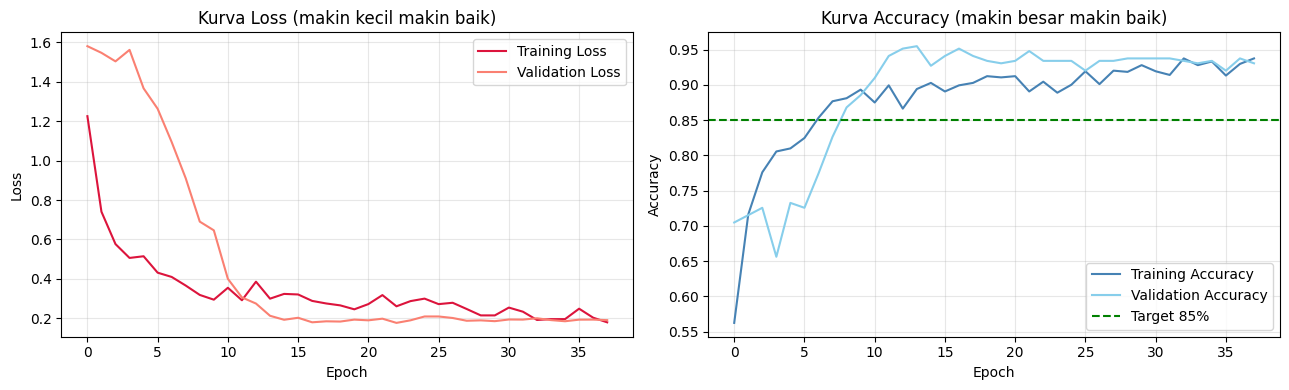

Grafik disimpan → saved_model/training_curve.png


In [17]:
# ── Grafik Kurva Training ─────────────────────────────────────────────────────
# Grafik ini menunjukkan bagaimana loss dan accuracy berubah tiap epoch
# Untuk mendeteksi:
#   - Overfitting : training acc terus naik, val acc mulai turun
#   - Underfitting: keduanya rendah dan tidak naik

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# Grafik kiri: Loss
ax1.plot(history.history["loss"],     label="Training Loss",   color="crimson")
ax1.plot(history.history["val_loss"], label="Validation Loss", color="salmon")
ax1.set_title("Kurva Loss (makin kecil makin baik)")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Grafik kanan: Accuracy
ax2.plot(history.history["accuracy"],     label="Training Accuracy",   color="steelblue")
ax2.plot(history.history["val_accuracy"], label="Validation Accuracy", color="skyblue")
# Garis putus-putus hijau = target akurasi 85%
ax2.axhline(y=0.85, color="green", linestyle="--", linewidth=1.5, label="Target 85%")
ax2.set_title("Kurva Accuracy (makin besar makin baik)")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("saved_model/training_curve.png", dpi=100, bbox_inches="tight")
plt.show()
print("Grafik disimpan → saved_model/training_curve.png")

## Step 12 — Simpan Model, Scaler & Daftar Fitur

In [18]:
# ── Simpan model ─────────────────────────────────────────────────────────────
# model.save() menyimpan SELURUH model:
#   - Arsitektur (susunan layer)
#   - Bobot yang sudah dipelajari selama training
#   - Konfigurasi optimizer dan loss function
# Format .keras adalah format TensorFlow terbaru
model.save(MODEL_PATH)
print(f"Model disimpan   → {MODEL_PATH}")

# ── Simpan scaler ─────────────────────────────────────────────────────────────
# WAJIB DISIMPAN! Scaler harus dipakai ulang saat inference
# Kenapa? Scaler menyimpan nilai min dan max dari data training
# Kalau pakai scaler baru saat inference → normalisasi berbeda → prediksi salah
joblib.dump(scaler, SCALER_PATH)
print(f"Scaler disimpan  → {SCALER_PATH}")

# ── Simpan nama fitur ─────────────────────────────────────────────────────────
# Nama dan URUTAN fitur harus sama persis antara training dan inference
# Kalau urutan berbeda → model mendapat input yang salah → prediksi kacau
with open(FEATURES_PATH, "w") as f:
    for nama in feat_names:
        f.write(nama + "\n")   # tulis satu nama per baris
print(f"Fitur disimpan   → {FEATURES_PATH}")

print("\nSemua file tersimpan di folder saved_model/ ✓")
print("Upload folder ini ke server backend setelah selesai.")

Model disimpan   → saved_model/placement_model.keras
Scaler disimpan  → saved_model/placement_scaler.pkl
Fitur disimpan   → saved_model/feature_names.txt

Semua file tersimpan di folder saved_model/ ✓
Upload folder ini ke server backend setelah selesai.


## Step 13 — Inference
> Simulasi: bagaimana model dipanggil saat siswa selesai pre-test di aplikasi web

### Format yang disepakati dengan Full-Stack:

**Input dari Backend → AI:**
```json
[
  {"user_id": "stu_0001", "no_soal": 1, "materi": "penjumlahan", "benar_salah": 1, "waktu_pengerjaan": 12.5},
  {"user_id": "stu_0001", "no_soal": 2, "materi": "pengurangan", "benar_salah": 0, "waktu_pengerjaan": 34.2}
]
```

**Output AI → Backend:**
```json
[
  {"user_id": "stu_0001", "mulai_dari_modul": 1, "confidence": 0.87}
]
```


In [19]:
# ── Load model dan scaler dari file ──────────────────────────────────────────
# Di aplikasi nyata, bagian load ini dijalankan SEKALI saat server FastAPI start
# Tidak perlu load ulang setiap ada request masuk

# Load model — sertakan custom objects agar TensorFlow tahu definisi kelas custom
model_loaded = keras.models.load_model(
    MODEL_PATH,
    custom_objects={
        "TopicAttentionLayer"     : TopicAttentionLayer,
        "WeightedCrossEntropyLoss": WeightedCrossEntropyLoss,
    }
)

# Load scaler yang sama dipakai saat training
scaler_loaded = joblib.load(SCALER_PATH)

# Baca daftar nama fitur dari file teks
feat_names_loaded = open(FEATURES_PATH).read().splitlines()

print("Model, scaler, dan daftar fitur berhasil di-load ✓")

c:\Users\Acer\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\layer.py:427: UserWarning: `build()` was called on layer 'topic_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(



Model, scaler, dan daftar fitur berhasil di-load ✓


In [20]:
def predict_placement_batch(data_pretest: list, model, scaler, feat_names) -> list:
    """
    Memprediksi level awal untuk SATU atau LEBIH siswa sekaligus.
    Ini yang akan dibungkus oleh endpoint FastAPI /predict/placement.

    Args:
        data_pretest : list of dict — data pre-test dari backend
                       Format: [{"user_id", "no_soal", "materi",
                                 "benar_salah", "waktu_pengerjaan"}, ...]
        model        : model yang sudah di-load
        scaler       : scaler yang sudah di-load
        feat_names   : daftar nama fitur (urutan harus sama saat training)

    Returns:
        list of dict — hasil prediksi siap dikirim ke backend
        Format: [{"user_id", "mulai_dari_modul", "confidence"}, ...]
    """

    # LANGKAH 1: Ubah list of dict menjadi DataFrame
    df_input = pd.DataFrame(data_pretest)

    # LANGKAH 2: Hitung akurasi per materi per siswa
    # Sama persis dengan preprocessing saat training
    akurasi_per_materi = (
        df_input.groupby(["user_id", "materi"])["benar_salah"]
        .mean()
        .unstack(fill_value=0)   # materi → kolom
    )
    # Tambah prefix 'akurasi_'
    akurasi_per_materi.columns = [f"akurasi_{m}" for m in akurasi_per_materi.columns]

    # LANGKAH 3: Hitung rata-rata waktu per materi per siswa
    avg_waktu_per_materi = (
        df_input.groupby(["user_id", "materi"])["waktu_pengerjaan"]
        .mean()
        .unstack(fill_value=0)
    )
    # Tambah prefix 'avg_waktu_'
    avg_waktu_per_materi.columns = [f"avg_waktu_{m}" for m in avg_waktu_per_materi.columns]

    # LANGKAH 4: Gabungkan semua fitur
    df_siswa = akurasi_per_materi.merge(avg_waktu_per_materi, on="user_id", how="inner")

    # LANGKAH 5: Sesuaikan kolom dengan feat_names saat training
    # Siswa mungkin tidak mengerjakan semua materi → tambahkan kolom yang kurang dengan 0
    # reindex() = atur ulang kolom sesuai urutan feat_names, kolom baru diisi 0
    df_siswa = df_siswa.reindex(columns=feat_names, fill_value=0)

    # Simpan user_id sebelum diubah ke array
    user_ids_input = df_siswa.index.tolist()

    # LANGKAH 6: Normalisasi menggunakan scaler yang SAMA saat training
    # transform() bukan fit_transform() — kita tidak belajar dari data baru
    X_input = scaler.transform(df_siswa.values)

    # LANGKAH 7: Prediksi — hasilkan probabilitas per kelas untuk semua siswa
    proba_semua = model.predict(X_input, verbose=0)
    # proba_semua = array (n_siswa, 3) — 3 probabilitas per siswa

    # LANGKAH 8: Susun hasil output sesuai format yang disepakati dengan backend
    hasil = []
    for i, user_id in enumerate(user_ids_input):
        proba       = proba_semua[i]                   # probabilitas 3 kelas untuk siswa ini
        level_index = int(np.argmax(proba))            # kelas dengan probabilitas tertinggi
        confidence  = float(proba[level_index])        # nilai probabilitas tertinggi

        # Format output yang dikirim ke backend — HANYA user_id dan mulai_dari_modul
        # Field lain (level, confidence) disertakan sebagai informasi tambahan
        hasil.append({
            "user_id"          : user_id,
            "mulai_dari_modul" : MODUL_MAP[level_index],   # ← dikirim ke backend
            "confidence"       : round(confidence, 4),      # ← dikirim ke backend
        })

    return hasil


print("Fungsi predict_placement_batch() siap ✓")

Fungsi predict_placement_batch() siap ✓


In [21]:
# ── Simulasi: request masuk dari backend ─────────────────────────────────────
# Ini menyimulasikan data yang dikirim backend ke endpoint /predict/placement

contoh_request = [
    # Siswa 1: akurasi rendah, waktu lama → kemungkinan pemula
    {"user_id": "stu_A", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 55.0},
    {"user_id": "stu_A", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 0, "waktu_pengerjaan": 62.0},
    {"user_id": "stu_A", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 48.0},
    {"user_id": "stu_A", "no_soal": 4, "materi": "penjumlahan",  "benar_salah": 0, "waktu_pengerjaan": 70.0},
    {"user_id": "stu_A", "no_soal": 5, "materi": "pembagian",    "benar_salah": 0, "waktu_pengerjaan": 80.0},

    # Siswa 2: akurasi tinggi, waktu cepat → kemungkinan mahir
    {"user_id": "stu_B", "no_soal": 1, "materi": "penjumlahan",  "benar_salah": 1, "waktu_pengerjaan": 8.0},
    {"user_id": "stu_B", "no_soal": 2, "materi": "pengurangan",  "benar_salah": 1, "waktu_pengerjaan": 9.0},
    {"user_id": "stu_B", "no_soal": 3, "materi": "perkalian",    "benar_salah": 1, "waktu_pengerjaan": 7.5},
    {"user_id": "stu_B", "no_soal": 4, "materi": "aljabar",      "benar_salah": 1, "waktu_pengerjaan": 12.0},
    {"user_id": "stu_B", "no_soal": 5, "materi": "geometri",     "benar_salah": 1, "waktu_pengerjaan": 11.0},
]

# Jalankan prediksi
hasil_prediksi = predict_placement_batch(
    contoh_request, model_loaded, scaler_loaded, feat_names_loaded
)

# ── Tampilkan hasil ───────────────────────────────────────────────────────────
print("=" * 55)
print("HASIL PREDIKSI PLACEMENT")
print("=" * 55)
for hasil in hasil_prediksi:
    print(f"\nuser_id          : {hasil['user_id']}")
    print(f"mulai_dari_modul : {hasil['mulai_dari_modul']}")
    print(f"confidence       : {hasil['confidence']*100:.1f}%")

print("\n" + "=" * 55)
print("FORMAT JSON YANG DIKIRIM KE BACKEND:")
print("=" * 55)
# Tampilkan dalam format JSON yang bersih
print(json.dumps(hasil_prediksi, indent=2, ensure_ascii=False))

HASIL PREDIKSI PLACEMENT

user_id          : stu_A
mulai_dari_modul : 1
confidence       : 100.0%

user_id          : stu_B
mulai_dari_modul : 8
confidence       : 89.8%

FORMAT JSON YANG DIKIRIM KE BACKEND:
[
  {
    "user_id": "stu_A",
    "mulai_dari_modul": 1,
    "confidence": 0.9999
  },
  {
    "user_id": "stu_B",
    "mulai_dari_modul": 8,
    "confidence": 0.8982
  }
]


## Selesai!

### File yang dihasilkan di `saved_model/`:
| File | Fungsi |
|------|--------|
| `placement_model.keras` | Model terlatih — di-load oleh server FastAPI |
| `placement_scaler.pkl` | Scaler normalisasi — wajib di-load bersama model |
| `feature_names.txt` | Daftar & urutan fitur — harus sama saat inference |
| `training_log.csv` | Log metrik tiap epoch |
| `training_curve.png` | Grafik loss & accuracy |

### File template data di `data/`:
| File | Fungsi |
|------|--------|
| `contoh_pretest.csv` | Template format CSV untuk tim Full-Stack |
| `contoh_pretest.json` | Template format JSON untuk tim Full-Stack |

### Langkah berikutnya:
1. **Bagikan** `data/contoh_pretest.csv` atau `data/contoh_pretest.json` ke tim Full-Stack sebagai referensi format data
2. **Ganti data dummy** di Step 5 dengan data nyata menggunakan Opsi A (CSV) atau Opsi B (JSON)
3. **Jalankan ulang** notebook dari Step 7 jika akurasi belum mencapai 85%
4. **Upload** folder `saved_model/` ke server backend
5. **Bungkus** fungsi `predict_placement_batch()` ke dalam endpoint FastAPI `/predict/placement`
